# AI直觉与科学计算基础

本课程旨在建立对人工智能核心逻辑的数学直觉，并掌握将物理/工程现实转化为计算机语言的基础工具。

## 核心议题
1. **范式转移**：从规则编程到深度学习的思维演进
2. **科学可视化**：利用 Python、NumPy 与 Matplotlib 进行数据透视
3. **数据形态学**：张量（Tensors）的空间直觉及其在神经网络中的映射

## 1. 机器学习重塑思维：辨析规则编程、机器学习与深度学习

在传统的工程计算中，我们依赖先验的物理或数学公式。而在复杂系统中，我们往往只拥有观测数据，需要让机器去“逆向工程”背后的规律。

*   **规则编程 (Rule-based)**：输入数据 $X$ + 人工定义的规则 $f(x)$ $\rightarrow$ 输出结果 $Y$。
    *   *逻辑*：我们知道系统的精确解析解。
*   **机器学习 (Machine Learning)**：输入数据 $X$ + 观测结果 $Y$ $\rightarrow$ 算法拟合出规则 $f(x)$。
    *   *逻辑*：算法（如支持向量机、随机森林）通过统计学方法寻找输入与输出的映射关系。
*   **深度学习 (Deep Learning)**：输入海量/非结构化数据 $X$ + 观测结果 $Y$ $\rightarrow$ 神经网络通过特征自提取，逼近极其复杂的非线性函数 $f(x)$。
    *   *逻辑*：利用多层感知机（MLP）的非线性激活和反向传播，实现特征工程的自动化。

**案例演示**：假设我们正在测量一个弹簧的拉力与伸长量的关系（胡克定律 $F = kx$）。

真实物理常数 k: 5.0
机器通过数据学习到的参数 w (即 k 的估计): 4.8550, 偏置 b: 0.1611


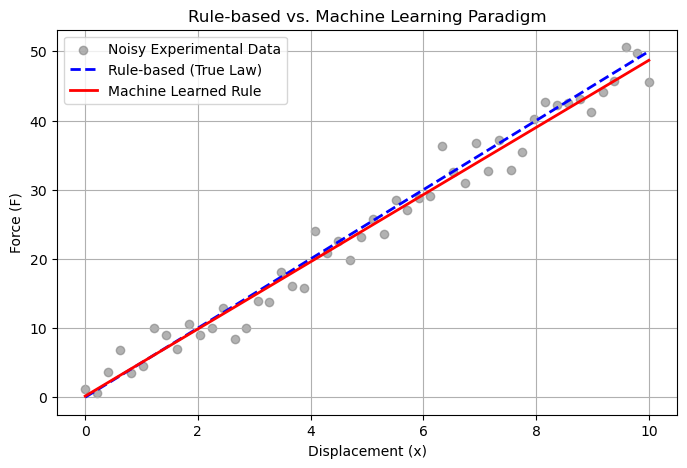

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 规则编程 (Rule-based) - 我们知道定律 F = kx
# ==========================================
def rule_based_hookes_law(x, k=5.0):
    """人工定义规则"""
    return k * x

# ==========================================
# 2. 机器学习思维 (Machine Learning) - 我们只有含噪数据，让机器寻找 k
# ==========================================
# 制造实验数据 (含高斯噪声)
np.random.seed(42)
X_data = np.linspace(0, 10, 50) 
Y_true = 5.0 * X_data
Y_noisy = Y_true + np.random.normal(0, 2.5, size=X_data.shape)

# 机器通过最小二乘法“学习”出权重 k (w) 和 偏置 b
# 目标是最小化 Loss: sum((Y_noisy - (w*X_data + b))^2)
w, b = np.polyfit(X_data, Y_noisy, 1) 

print(f"真实物理常数 k: 5.0")
print(f"机器通过数据学习到的参数 w (即 k 的估计): {w:.4f}, 偏置 b: {b:.4f}")

# 绘制对比图
plt.figure(figsize=(8, 5))
plt.scatter(X_data, Y_noisy, color='gray', label='Noisy Experimental Data', alpha=0.6)
plt.plot(X_data, rule_based_hookes_law(X_data), 'b--', label='Rule-based (True Law)', linewidth=2)
plt.plot(X_data, w * X_data + b, 'r-', label='Machine Learned Rule', linewidth=2)
plt.xlabel('Displacement (x)')
plt.ylabel('Force (F)')
plt.title('Rule-based vs. Machine Learning Paradigm')
plt.legend()
plt.grid(True)
plt.show()

## 2. 科学数据可视化：NumPy与Matplotlib的协同

在工程项目中（如具身智能的传感器回传、信号处理分析），我们面对的是庞大的数据阵列。**NumPy** 提供了高性能的多维数组对象（`ndarray`），而 **Matplotlib** 则是将这些数字矩阵转化为人类可理解的几何直觉的工具。

**核心工作流**：
1. **数据读取/生成**：将物理现象离散化为 NumPy 数组。
2. **数据处理**：利用向量化计算（Vectorization）替代低效的 `for` 循环，进行平滑、滤波或微积分运算。
3. **可视化渲染**：利用 Matplotlib 构建图床（Figure）和坐标系（Axes），绘制具有学术发表级标准的数据曲线。

**实操演示**：模拟并处理一个阻尼振荡系统的传感器信号（例如：机械臂末端的震动衰减或流体阻尼）。公式为 $y(t) = A e^{-\lambda t} \cos(\omega t)$。

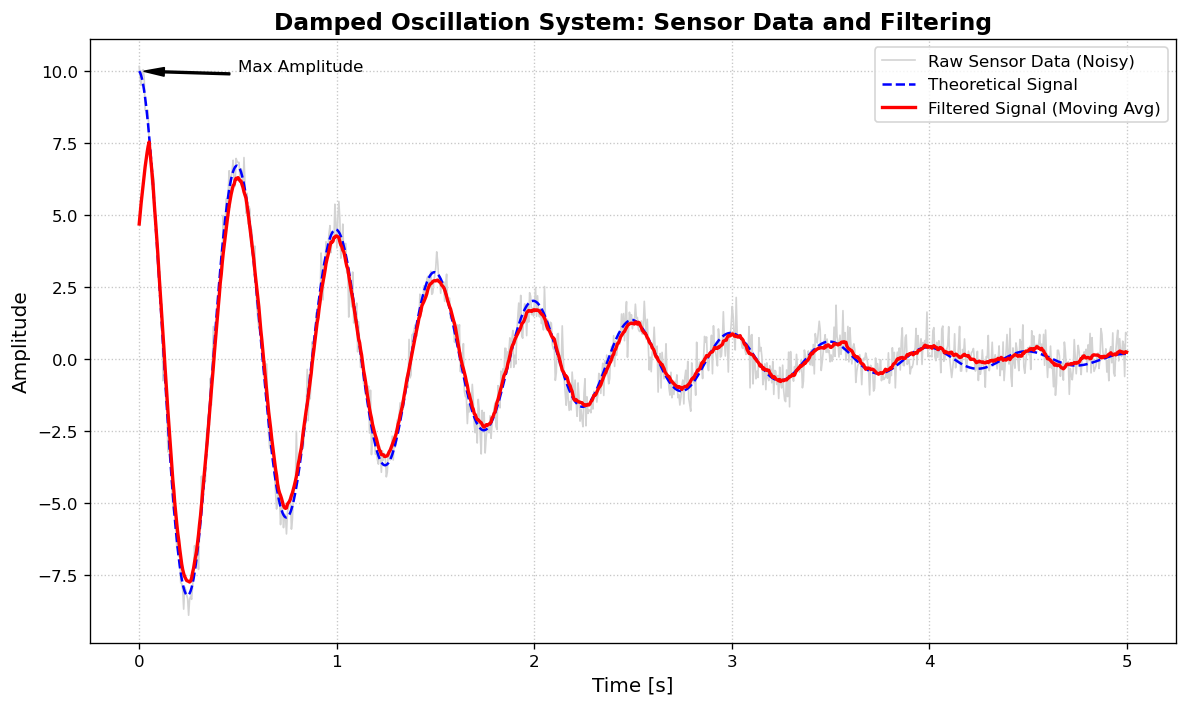

In [7]:
# 1. 数据生成：模拟高频采样的物理时间序列
t = np.linspace(0, 5, 1000)  # 5秒钟，1000个采样点
A = 10.0                     # 初始振幅
decay_rate = 0.8             # 衰减系数
omega = 2 * np.pi * 2        # 角频率 (2 Hz)

# NumPy 向量化运算 (无需循环，直接对整个矩阵进行计算)
y_clean = A * np.exp(-decay_rate * t) * np.cos(omega * t)
y_sensor = y_clean + np.random.normal(0, 0.5, size=t.shape) # 加入传感器读数噪声

# 2. 数据处理：简单的移动平均滤波 (Moving Average) 去噪
window_size = 20
window = np.ones(window_size) / window_size
y_filtered = np.convolve(y_sensor, window, mode='same')

# 3. 科学级可视化
fig, ax = plt.subplots(figsize=(10, 6), dpi=120) # 设置画布大小和分辨率

# 绘制三条不同的曲线，展示处理前后的对比
ax.plot(t, y_sensor, color='lightgray', linewidth=1, label='Raw Sensor Data (Noisy)')
ax.plot(t, y_clean, color='blue', linestyle='--', linewidth=1.5, label='Theoretical Signal')
ax.plot(t, y_filtered, color='red', linewidth=2, label='Filtered Signal (Moving Avg)')

# 学术规范化设置
ax.set_title('Damped Oscillation System: Sensor Data and Filtering', fontsize=14, fontweight='bold')
ax.set_xlabel('Time [s]', fontsize=12)
ax.set_ylabel('Amplitude', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='upper right', frameon=True)

# 标注特定事件（例如最大振幅位置）
max_idx = np.argmax(y_clean)
ax.annotate('Max Amplitude', xy=(t[max_idx], y_clean[max_idx]), 
            xytext=(t[max_idx]+0.5, y_clean[max_idx]),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.show()

## 3. 数据的基本形态：认识张量及其在网络中的作用

无论我们处理的是控制指令、一维音频、二维图像，还是三维的环境点云，在深度学习框架（如 PyTorch / TensorFlow）中，这些信息最终都被统一抽象为**张量 (Tensor)**。

*   **标量 (Scalar - 0D Tensor)**：单纯的数值。例如：损失值 (Loss)、学习率。形状: `[]`
*   **向量 (Vector - 1D Tensor)**：一维数组。例如：传感器的时间序列、神经网络的偏置项 (Bias)。形状: `[N]`
*   **矩阵 (Matrix - 2D Tensor)**：二维数组。例如：灰度图像、全连接层的权重矩阵 (Weights)。形状: `[H, W]`
*   **高阶张量 (3D/ND Tensor)**：
    *   3D 张量：RGB 彩色图像 `[Channels, Height, Width]`，或 NLP 中的词向量序列。
    *   4D 张量：图像的批次 (Batch) `[Batch_Size, Channels, Height, Width]`。

**张量在神经网络中的核心作用**：
神经网络的前向传播本质上是连续的**张量仿射变换 (Affine Transformation)** 与 **非线性激活 (Non-linear Activation)**。
其核心线性代数表达为：$Y = X \cdot W^T + b$
其中，$X$ 是输入张量，$W$ 是权重张量，$b$ 是偏置张量，$Y$ 是输出张量。

In [10]:
import torch

print("--- 1. 张量的维度构造 ---")
# 0D 标量
scalar = torch.tensor(3.1415)
print(f"标量 (0D): {scalar}, Shape: {scalar.shape}")

# 1D 向量
vector = torch.tensor([1.0, 2.0, 3.0, 4.0])
print(f"向量 (1D): {vector}, Shape: {vector.shape}")

# 2D 矩阵
matrix = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
print(f"矩阵 (2D): \n{matrix}\nShape: {matrix.shape}")

# 3D 张量 (例如：2张 RGB 图片，像素为 2x2)
# 形状: [Batch_Size, Channels, Height, Width] -> 这里以 [2, 3, 2, 2] 为例
tensor_4d = torch.rand(2, 3, 2, 2) 
print(f"4D 张量 (常用于CV视觉任务): \nShape: {tensor_4d.shape}")

print("\n--- 2. 张量在神经网络中的作用：模拟一个全连接层 (Linear Layer) ---")
# 假设我们有一个输入数据批次，包含 4 个样本，每个样本提取了 3 个特征
# X shape: [Batch_Size, In_Features] = [4, 3]
X = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0],
                  [7.0, 8.0, 9.0],
                  [0.1, 0.2, 0.3]])

# 定义网络层的参数
in_features = 3
out_features = 2  # 将3维特征映射到2维特征空间 (例如分类任务的 logits)

# 权重矩阵 W shape: [Out_Features, In_Features] = [2, 3]
W = torch.randn(out_features, in_features)

# 偏置向量 b shape: [Out_Features] = [2]
b = torch.randn(out_features)

# 执行矩阵乘法运算：Y = X @ W.T + b
# 注意：X 的形状是 [4, 3]，W 的转置形状是 [3, 2]，相乘得到 [4, 2]
Y = torch.matmul(X, W.t()) + b 

print(f"输入特征张量 X 形状: {X.shape}")
print(f"权重参数张量 W 形状: {W.shape}")
print(f"输出结果张量 Y: \n{Y}\n输出形状: {Y.shape}")

ModuleNotFoundError: No module named 'torch'